# Screen wells for color

The data was pu together from different dataset resulting from different experiment and read by the plate reader. 
First we use datasets with 20nm step.

## Packages and methodology

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline

import joblib


### Data processing

The blank is removed in excel : I take the mean of all the control wells from the given set of measures

As the absorbance measures can be very different among samples due to cell or pigment concentration - which is not the signal we are looking for - we have to rescale the values for them to fall in the same order of magnitude. For that, we apply an arcsin transformation to the dataset.

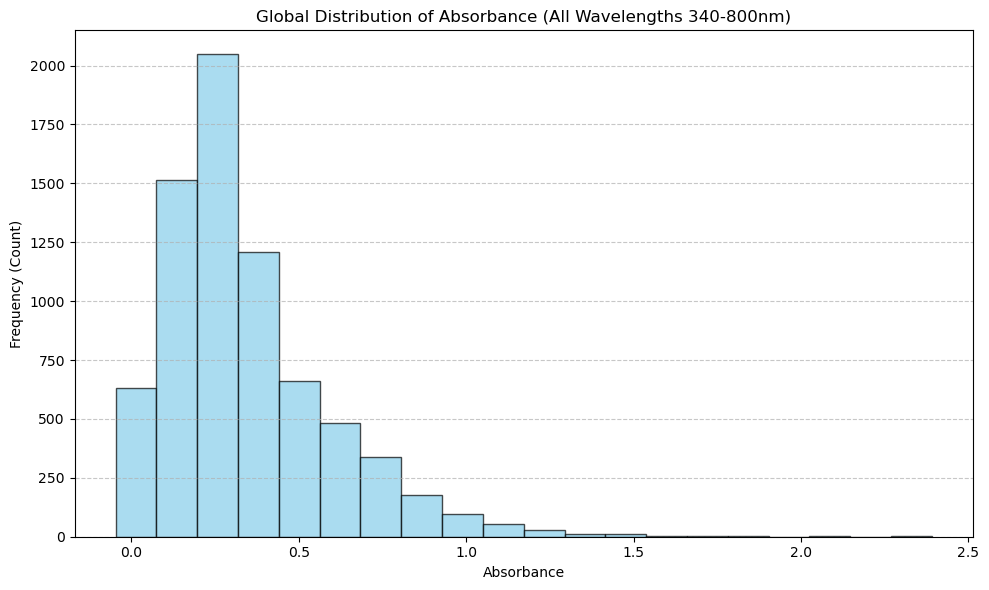

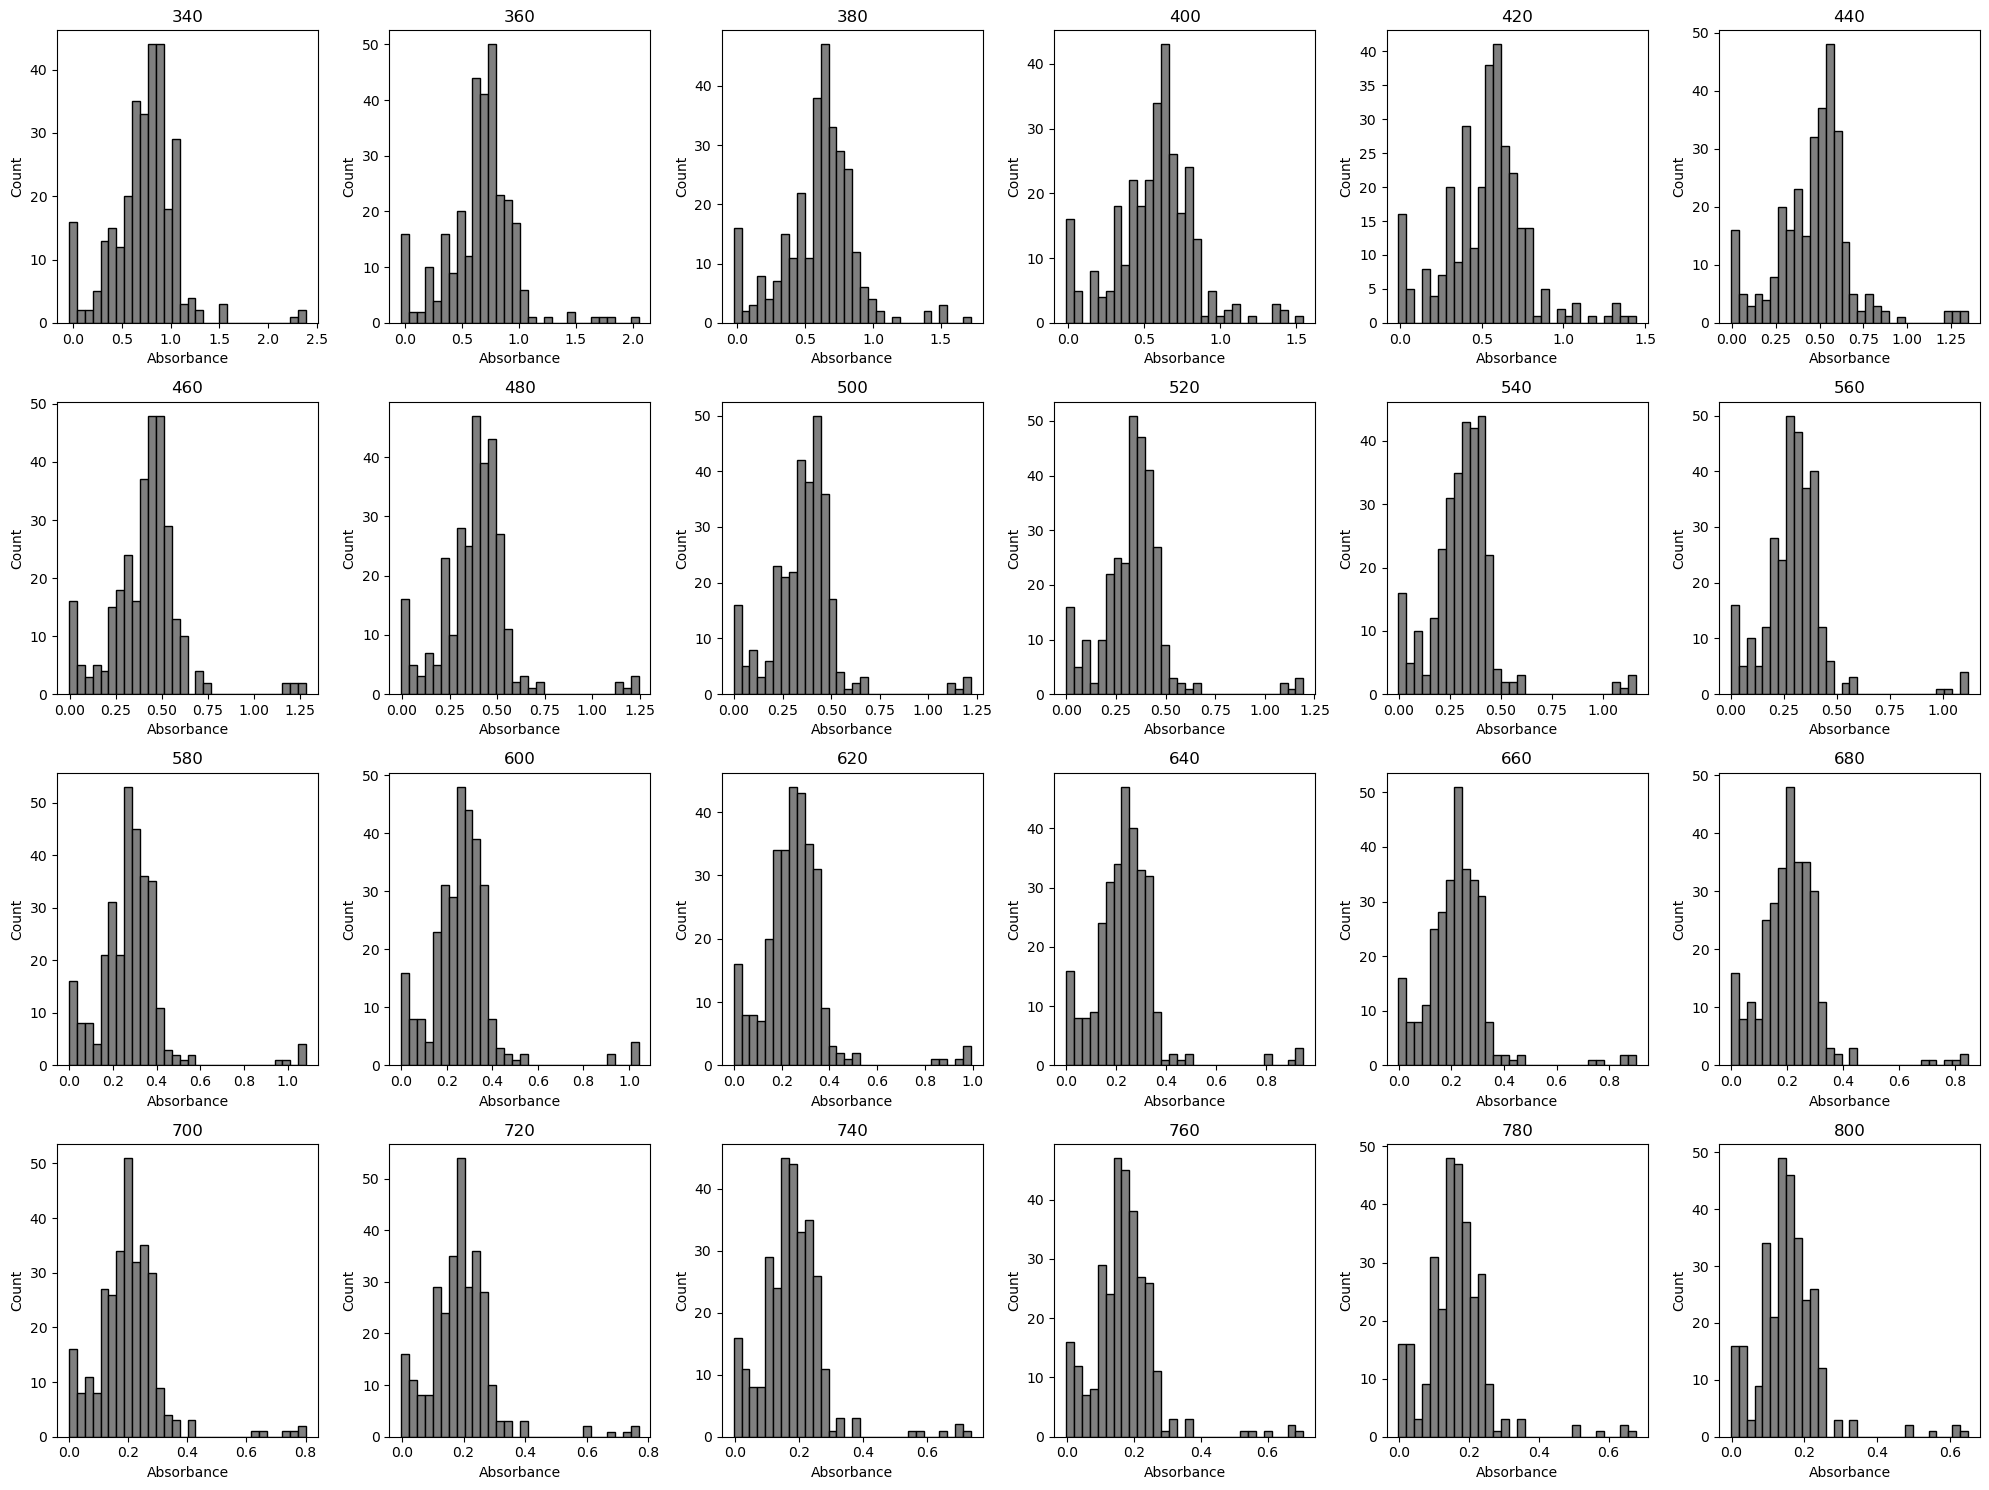

In [2]:
# --- 1. LOAD & PREPARE DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_mblank_R2B.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)
IDs = df.iloc[:0]
abs_columns = df.loc[:, '340':'800']
tags = df.iloc[:,25:27]

# Visualizing data
# 3. Data Cleaning for Plotting
# Flatten the dataframe to a single list of values for the global histogram
# dropna() removes empty wells, clip(lower=0) removes negative noise from blank subtraction
all_values = abs_columns.values.flatten()
all_values = all_values[~np.isnan(all_values)] # Remove NaNs
#all_values = all_values[all_values >= 0]       # Remove negatives

# --- Plot 1: Global Histogram (All Wavelengths Combined) ---
plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Global Distribution of Absorbance (All Wavelengths 340-800nm)')
plt.xlabel('Absorbance')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
 

# Select columns
cols = df.loc[:, '340':'800'].columns

# Create one big figure
plt.figure(figsize=(20, 15))

# Loop through each column and plot
for i, col in enumerate(cols):
    plt.subplot(4, 6, i+1)  # Adjust 4x6 grid if you have more/fewer columns
    plt.hist(df[col].dropna(), bins=30, color='gray', edgecolor='black')
    plt.title(col)
    plt.xlabel('Absorbance')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Arcsin transformation
#transformed_data = np.arcsinh(abs_columns)

#dftransformed = pd.concat([IDs,transformed_data], axis=1)

#print(dftransformed.head())

### generate dataset for each label framework

## PCA on wavelengths

✅ Data loaded: 322 samples, 24 wavelengths
📊 PCA Explained Variance: PC1=95.00%, PC2=3.85%
💡 Total variance captured by 2D plot: 98.84%


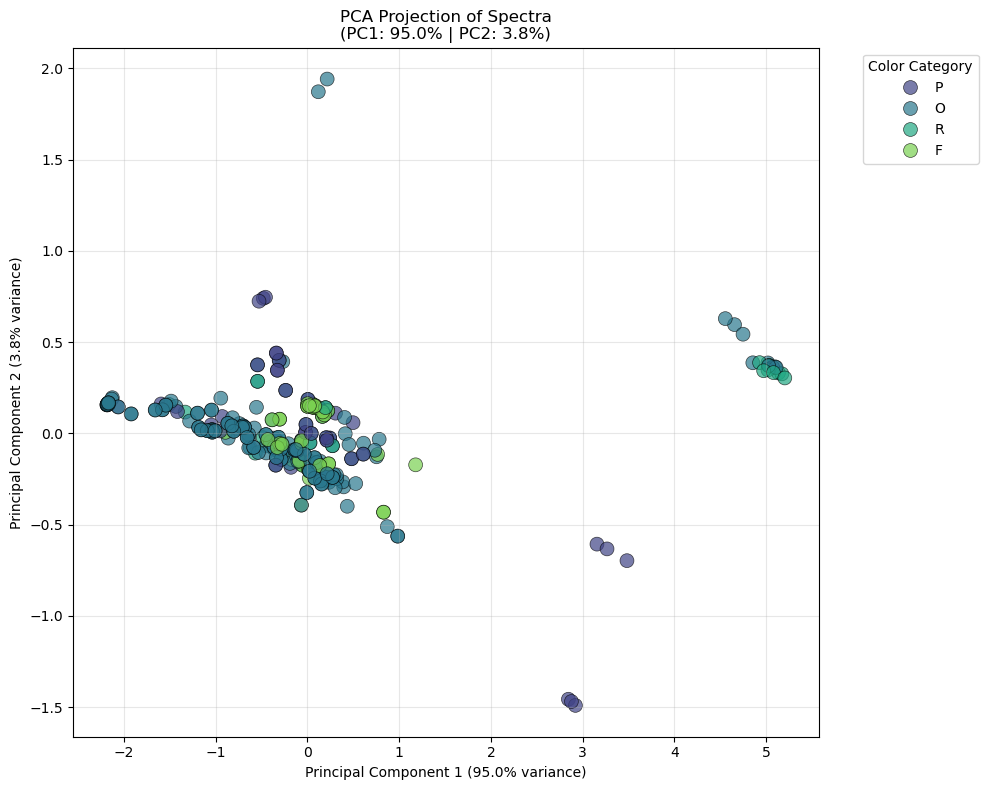

In [3]:
# --- 1. LOAD & PREPARE DATA (Same as before) --- TO UPDATE WITH TRANSFORMATION IN ALL CELLS
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_OPRF.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)

# CONFIGURATION
label_col = 'Color_label'
id_col = 'SampleID'  # <--- Ensure this matches your ID column name

cols_to_drop = [label_col]
if id_col in df.columns:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop).apply(pd.to_numeric, errors='coerce')
y = df[label_col]

# Drop rows with NaNs if any
mask = ~X.isnull().any(axis=1)
X = X[mask]
y = y[mask]

print(f"✅ Data loaded: {X.shape[0]} samples, {X.shape[1]} wavelengths")

# --- 2. STANDARDIZE DATA (Crucial for PCA) ---
# PCA is sensitive to scale. Spectra usually have similar scales, but standardizing is best practice.
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# --- 3. PERFORM PCA ---
# We reduce to 2 components for easy 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Color_Label': y
})

explained_var = pca.explained_variance_ratio_
print(f"📊 PCA Explained Variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}")
print(f"💡 Total variance captured by 2D plot: {sum(explained_var):.2%}")

# --- 4. PLOT PCA RESULTS ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Color_Label', 
    palette='viridis', 
    s=100, 
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)
plt.title(f'PCA Projection of Spectra\n(PC1: {explained_var[0]:.1%} | PC2: {explained_var[1]:.1%})')
plt.xlabel(f'Principal Component 1 ({explained_var[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]:.1%} variance)')
plt.legend(title='Color Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



C'est pas une pcq du feu de dieu... let's try with binary labels !

## Binary labels

✅ Data loaded: 322 samples, 24 wavelengths
📊 PCA Explained Variance: PC1=95.00%, PC2=3.85%
💡 Total variance captured by 2D plot: 98.84%


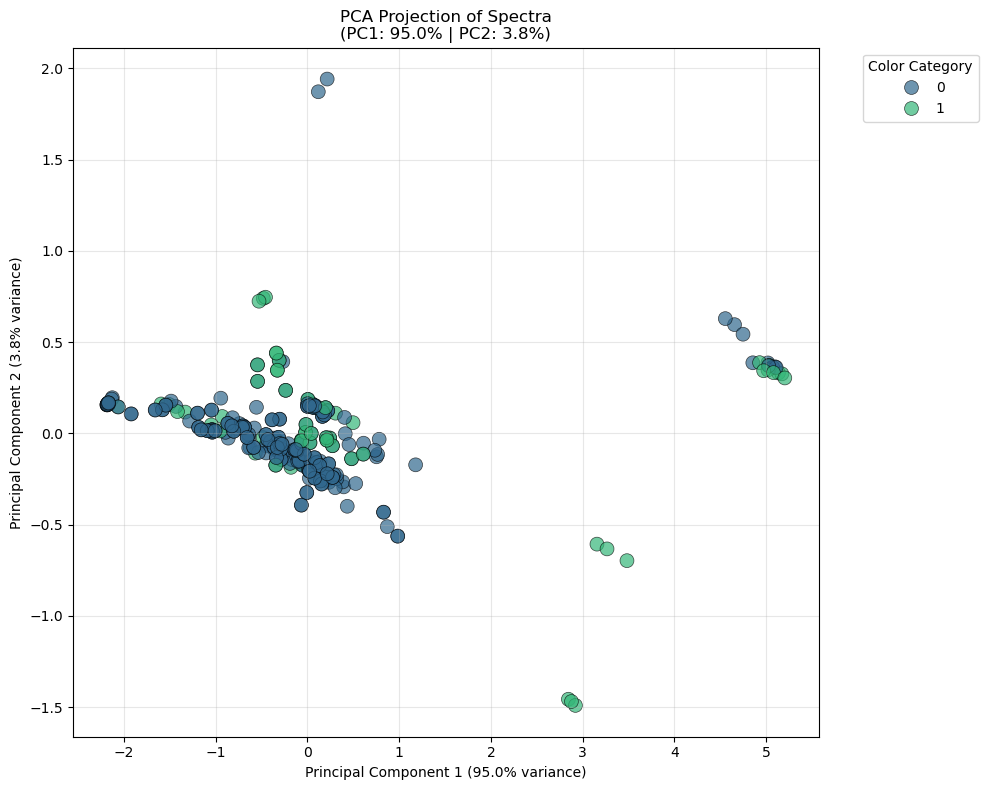

In [5]:
# --- 1. LOAD & PREPARE DATA (Same as before) ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_binary.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)

# CONFIGURATION
label_col = 'Binary'
id_col = 'SampleID'  # <--- Ensure this matches your ID column name

cols_to_drop = [label_col]
if id_col in df.columns:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop).apply(pd.to_numeric, errors='coerce')
y = df[label_col]

# Drop rows with NaNs if any
mask = ~X.isnull().any(axis=1)
X = X[mask]
y = y[mask]

print(f"✅ Data loaded: {X.shape[0]} samples, {X.shape[1]} wavelengths")

# --- 2. STANDARDIZE DATA (Crucial for PCA) ---
# PCA is sensitive to scale. Spectra usually have similar scales, but standardizing is best practice.
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# --- 3. PERFORM PCA ---
# We reduce to 2 components for easy 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Color_Label': y
})

explained_var = pca.explained_variance_ratio_
print(f"📊 PCA Explained Variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}")
print(f"💡 Total variance captured by 2D plot: {sum(explained_var):.2%}")

# --- 4. PLOT PCA RESULTS ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Color_Label', 
    palette='viridis', 
    s=100, 
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)
plt.title(f'PCA Projection of Spectra\n(PC1: {explained_var[0]:.1%} | PC2: {explained_var[1]:.1%})')
plt.xlabel(f'Principal Component 1 ({explained_var[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]:.1%} variance)')
plt.legend(title='Color Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Still not amazing... keep going

## PCA scale labels

✅ Data loaded: 322 samples, 24 wavelengths
📊 PCA Explained Variance: PC1=95.00%, PC2=3.85%
💡 Total variance captured by 2D plot: 98.84%


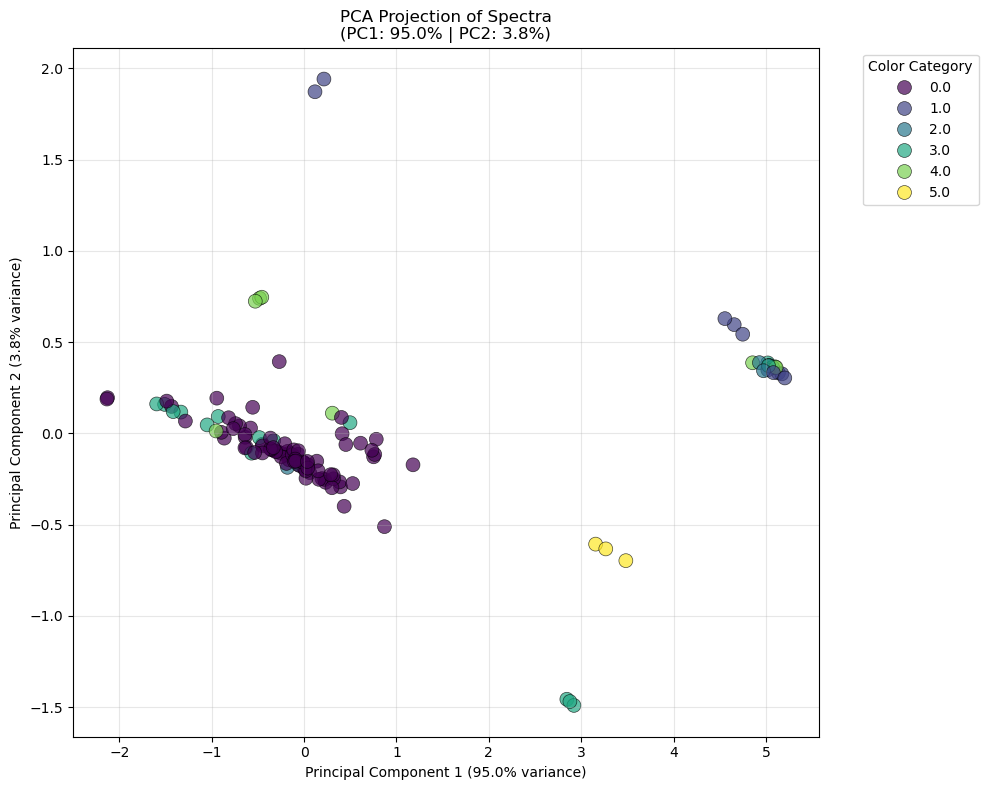

In [6]:
# --- 1. LOAD & PREPARE DATA (Same as before) ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_scale.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.astype(str)

# CONFIGURATION
label_col = 'scale_label'
id_col = 'SampleID'  # <--- Ensure this matches your ID column name

cols_to_drop = [label_col]
if id_col in df.columns:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop).apply(pd.to_numeric, errors='coerce')
y = df[label_col]

# Drop rows with NaNs if any
mask = ~X.isnull().any(axis=1)
X = X[mask]
y = y[mask]

print(f"✅ Data loaded: {X.shape[0]} samples, {X.shape[1]} wavelengths")

# --- 2. STANDARDIZE DATA (Crucial for PCA) ---
# PCA is sensitive to scale. Spectra usually have similar scales, but standardizing is best practice.
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# --- 3. PERFORM PCA ---
# We reduce to 2 components for easy 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Color_Label': y
})

explained_var = pca.explained_variance_ratio_
print(f"📊 PCA Explained Variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}")
print(f"💡 Total variance captured by 2D plot: {sum(explained_var):.2%}")

# --- 4. PLOT PCA RESULTS ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Color_Label', 
    palette='viridis', 
    s=100, 
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)
plt.title(f'PCA Projection of Spectra\n(PC1: {explained_var[0]:.1%} | PC2: {explained_var[1]:.1%})')
plt.xlabel(f'Principal Component 1 ({explained_var[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]:.1%} variance)')
plt.legend(title='Color Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Mhmh funny what's happening

In [5]:
# --- 5. BONUS: Train a Simple Linear Model on PCA Components ---
# This tells you: "If I only used these 2 dimensions, how well could I classify?"
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression is a linear classifier (straight lines boundaries)
linear_model = LogisticRegression(max_iter=1000)
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

linear_acc = accuracy_score(y_test, y_pred_linear)

# Compare with Random Forest (Reload or retrain quickly on full data for fair comparison)
# Retraining RF on full scaled data for fair comparison
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
rf_model = joblib.load("color_classifier.pkl") # Load your existing trained model
# Note: The loaded model expects original unscaled data if we didn't scale during training. 
# Let's retrain a fresh RF on the SAME split as the linear model for direct comparison.
from sklearn.ensemble import RandomForestClassifier
rf_fresh = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fresh.fit(X_train_full, y_train_full)
rf_pred = rf_fresh.predict(X_test_full)
rf_acc = accuracy_score(y_test_full, rf_pred)

print("\n🆚 MODEL COMPARISON (on same test split)")
print(f"📉 Linear Model (on 2 PCA components): {linear_acc:.2f} accuracy")
print(f"🌲 Random Forest (on all wavelengths):  {rf_acc:.2f} accuracy")
print(f"🚀 Gain from Complex Model:            {(rf_acc - linear_acc):.2f}")

if rf_acc > linear_acc + 0.05:
    print("💡 Insight: The Random Forest significantly outperforms the linear approach. Your spectral patterns are likely non-linear!")
else:
    print("💡 Insight: The linear model performs similarly. Your color classes might be linearly separable in spectral space.")

# --- 6. PLOT PCA LOADINGS (Optional but cool) ---
# Shows which wavelengths contribute most to PC1 and PC2
loadings = pca.components_
plt.figure(figsize=(12, 5))
plt.plot(X.columns, loadings[0], label='PC1 Loadings', linewidth=2)
plt.plot(X.columns, loadings[1], label='PC2 Loadings', linewidth=2, linestyle='--')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Loading Value')
plt.title('PCA Loadings: Which Wavelengths Drive the Separation?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ValueError: Input y contains NaN.

## Classes OPRF

In [ ]:


# --- 1. LOAD DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_OPRF.xlsx" 
print(f"📂 Loading data from {file_path}...")

try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print("❌ Error: File not found. Please check the filename and path.")
    exit()

# Transform excel numbers to string 
df.columns = df.columns.astype(str)
label_col = 'Color_label'
id_col = 'SampleID'

# Check if label column exists
if label_col not in df.columns:
    print(f"❌ Error: Column '{label_col}' not found.")
    exit()

# Check if ID column exists (optional)
if id_col and id_col not in df.columns:
    print(f"⚠️ Warning: ID column '{id_col}' not found. Ignoring ID column.")
    id_col = None


📂 Loading data from /Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_OPRF.xlsx...


In [ ]:
# --- 🛠️ STEP 2: PREPARE FEATURES (X) AND LABELS (y) ---
# Drop the Label column AND the ID column (if it exists) from features
cols_to_drop = [label_col]
if id_col:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop)
y = df[label_col]

# Optional: Keep IDs for later reference (e.g., to know which sample failed)
sample_ids = df[id_col] if id_col else None

# Ensure all feature columns (wavelengths) are numeric
# This forces any accidental text in wavelength columns to become NaN or errors out safely
X = X.apply(pd.to_numeric, errors='coerce')

# Drop rows where conversion failed (optional, but good for cleanliness)
if X.isnull().any().any():
    print("⚠️ Warning: Some non-numeric data found in wavelength columns. Dropping affected rows.")
    mask = ~X.isnull().any(axis=1)
    X = X[mask]
    y = y[mask]
    if sample_ids is not None:
        sample_ids = sample_ids[mask]

print(f"✅ Loaded {len(X)} samples with {len(X.columns)} wavelength features.")
print("🏷️  Classes found:", y.unique())



✅ Loaded 322 samples with 24 wavelength features.
🏷️  Classes found: ['P' 'O' 'R' 'F']


In [11]:
# --- 3. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📉 Training set: {len(X_train)} samples")
print(f"🧪 Test set: {len(X_test)} samples")

# --- 4. TRAIN THE MODEL ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("🚀 Training Random Forest classifier...")
model.fit(X_train, y_train)



📉 Training set: 257 samples
🧪 Test set: 65 samples
🚀 Training Random Forest classifier...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



📊 Evaluation Results:
Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           F       0.60      0.30      0.40        10
           O       0.72      0.83      0.77        41
           P       0.67      0.67      0.67         9
           R       0.50      0.40      0.44         5

    accuracy                           0.69        65
   macro avg       0.62      0.55      0.57        65
weighted avg       0.68      0.69      0.68        65



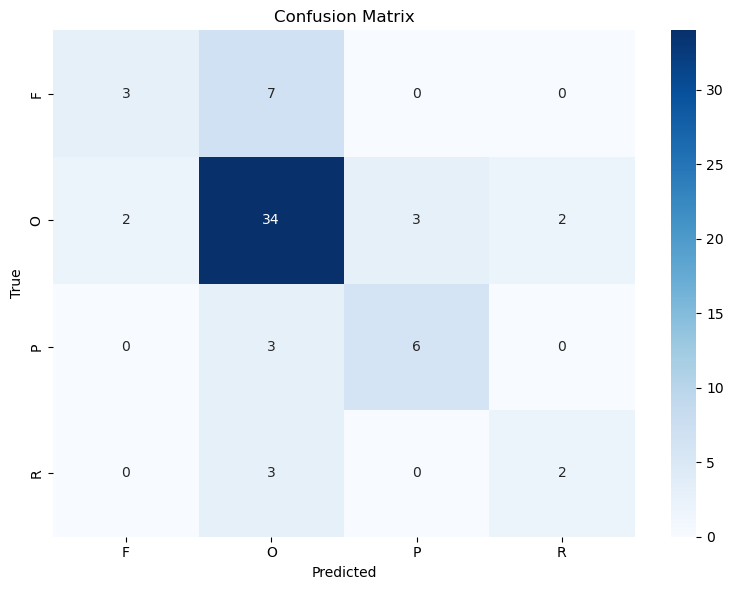

In [12]:
# --- 5. EVALUATE ---
y_pred = model.predict(X_test)

print("\n📊 Evaluation Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 6. PLOT CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

💾 Model saved to 'color_classifier.pkl'


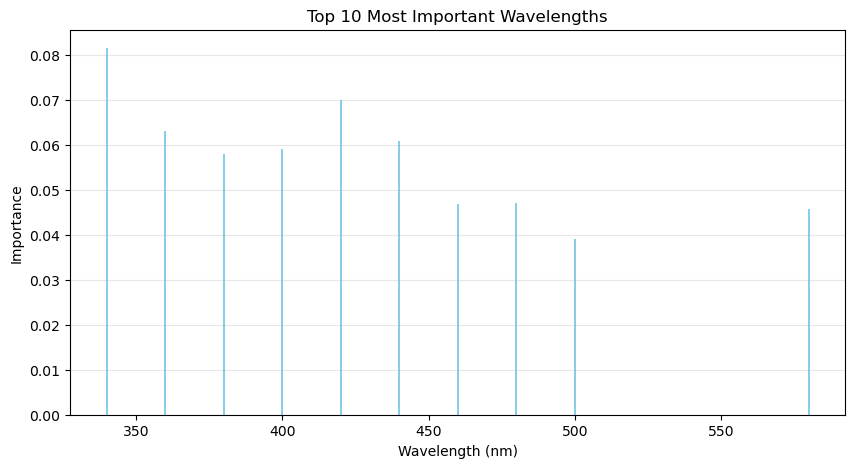

In [13]:
# --- 7. SAVE MODEL ---
joblib.dump(model, "color_classifier.pkl")
print("💾 Model saved to 'color_classifier.pkl'")

# --- 8. FEATURE IMPORTANCE ---
importances = model.feature_importances_
# Convert column names to float for plotting (assuming they are wavelengths like "400", "410")
try:
    feature_names = [float(c) for c in X.columns]
    top_10_idx = np.argsort(importances)[-10:][::-1]
    
    plt.figure(figsize=(10, 5))
    plt.bar([feature_names[i] for i in top_10_idx], importances[top_10_idx], color='skyblue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Importance')
    plt.title('Top 10 Most Important Wavelengths')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except ValueError:
    print("⚠️ Could not convert feature names to float for plotting (maybe they aren't wavelengths?). Skipping importance plot.")

## Binary classes

In [16]:
# --- 1. LOAD DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_binary.xlsx" 
print(f"📂 Loading data from {file_path}...")

try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print("❌ Error: File not found. Please check the filename and path.")
    exit()

# Transform excel numbers to string 
df.columns = df.columns.astype(str)
label_col = 'Binary' ### adapt to dataset
id_col = 'SampleID'

# Check if label column exists
if label_col not in df.columns:
    print(f"❌ Error: Column '{label_col}' not found.")
    exit()

# Check if ID column exists (optional)
if id_col and id_col not in df.columns:
    print(f"⚠️ Warning: ID column '{id_col}' not found. Ignoring ID column.")
    id_col = None

📂 Loading data from /Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_binary.xlsx...


In [17]:
# --- 🛠️ STEP 2: PREPARE FEATURES (X) AND LABELS (y) ---
# Drop the Label column AND the ID column (if it exists) from features
cols_to_drop = [label_col]
if id_col:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop)
y = df[label_col]

# Optional: Keep IDs for later reference (e.g., to know which sample failed)
sample_ids = df[id_col] if id_col else None

# Ensure all feature columns (wavelengths) are numeric
# This forces any accidental text in wavelength columns to become NaN or errors out safely
X = X.apply(pd.to_numeric, errors='coerce')

# Drop rows where conversion failed (optional, but good for cleanliness)
if X.isnull().any().any():
    print("⚠️ Warning: Some non-numeric data found in wavelength columns. Dropping affected rows.")
    mask = ~X.isnull().any(axis=1)
    X = X[mask]
    y = y[mask]
    if sample_ids is not None:
        sample_ids = sample_ids[mask]

print(f"✅ Loaded {len(X)} samples with {len(X.columns)} wavelength features.")
print("🏷️  Classes found:", y.unique())



✅ Loaded 322 samples with 24 wavelength features.
🏷️  Classes found: [1 0]


In [18]:
# --- 3. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📉 Training set: {len(X_train)} samples")
print(f"🧪 Test set: {len(X_test)} samples")

# --- 4. TRAIN THE MODEL ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("🚀 Training Random Forest classifier...")
model.fit(X_train, y_train)



📉 Training set: 257 samples
🧪 Test set: 65 samples
🚀 Training Random Forest classifier...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



📊 Evaluation Results:
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        51
           1       0.38      0.21      0.27        14

    accuracy                           0.75        65
   macro avg       0.59      0.56      0.56        65
weighted avg       0.71      0.75      0.73        65



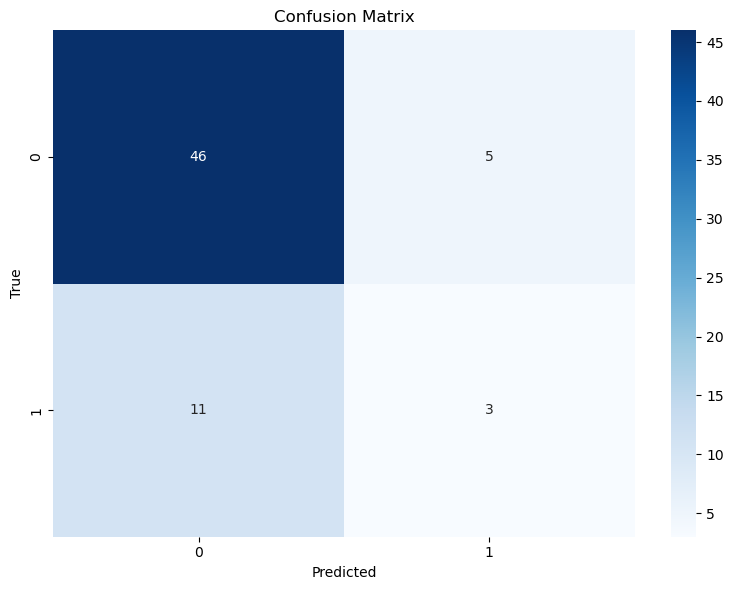

In [19]:
# --- 5. EVALUATE ---
y_pred = model.predict(X_test)

print("\n📊 Evaluation Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 6. PLOT CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

💾 Model saved to 'color_classifier.pkl'


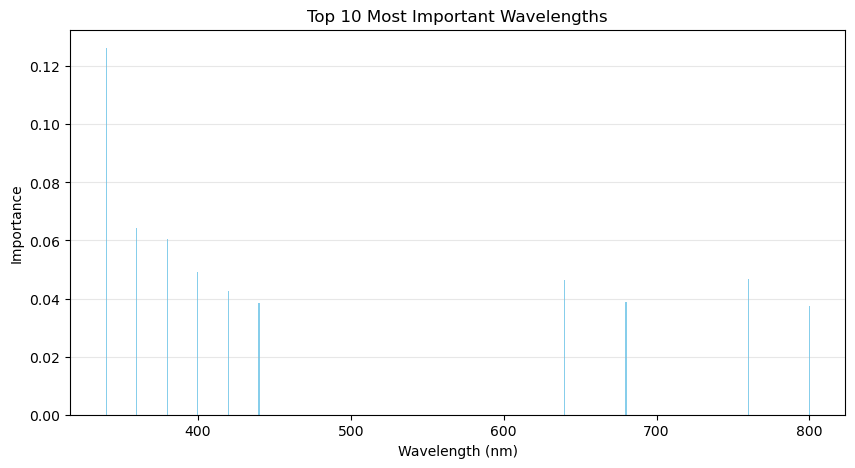

In [ ]:
# --- 7. SAVE MODEL ---
joblib.dump(model, "color_classifier_bin.pkl")
print("💾 Model saved to 'color_classifier_bin.pkl'")

# --- 8. FEATURE IMPORTANCE ---
importances = model.feature_importances_
# Convert column names to float for plotting (assuming they are wavelengths like "400", "410")
try:
    feature_names = [float(c) for c in X.columns]
    top_10_idx = np.argsort(importances)[-10:][::-1]
    
    plt.figure(figsize=(10, 5))
    plt.bar([feature_names[i] for i in top_10_idx], importances[top_10_idx], color='skyblue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Importance')
    plt.title('Top 10 Most Important Wavelengths')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except ValueError:
    print("⚠️ Could not convert feature names to float for plotting (maybe they aren't wavelengths?). Skipping importance plot.")

## Scale classes

In [4]:

# --- 1. LOAD DATA ---
file_path = "/Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_scale.xlsx"  # <-- Update this filename
print(f"📂 Loading data from {file_path}...")

try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print("❌ Error: File not found.")
    exit()

# --- 🛠️ STEP 1: IDENTIFY COLUMNS ---
# Convert all column names to strings to avoid mixed type errors
df.columns = df.columns.astype(str)

print("Columns found:", df.columns.tolist())

# Define your specific column names here
label_col = 'scale_label'
# If you have a Sample ID column (e.g., 'Sample_ID', 'CE4_C9', or 'Well'), put its name here.
# If you DON'T have a specific ID column and just want to use row numbers, set this to None.
id_col = 'SampleID'  # <--- CHANGE THIS to your actual ID column name if it exists

# Check if label column exists
if label_col not in df.columns:
    print(f"❌ Error: Column '{label_col}' not found.")
    exit()

# Check if ID column exists (optional)
if id_col and id_col not in df.columns:
    print(f"⚠️ Warning: ID column '{id_col}' not found. Ignoring ID column.")
    id_col = None

# --- 🛠️ STEP 2: PREPARE FEATURES (X) AND LABELS (y) ---
# Drop the Label column AND the ID column (if it exists) from features
cols_to_drop = [label_col]
if id_col:
    cols_to_drop.append(id_col)

X = df.drop(columns=cols_to_drop)
y = df[label_col]

# Optional: Keep IDs for later reference (e.g., to know which sample failed)
sample_ids = df[id_col] if id_col else None

# Ensure all feature columns (wavelengths) are numeric
# This forces any accidental text in wavelength columns to become NaN or errors out safely
X = X.apply(pd.to_numeric, errors='coerce')

# Drop rows where conversion failed (optional, but good for cleanliness)
if X.isnull().any().any():
    print("⚠️ Warning: Some non-numeric data found in wavelength columns. Dropping affected rows.")
    mask = ~X.isnull().any(axis=1)
    X = X[mask]
    y = y[mask]
    if sample_ids is not None:
        sample_ids = sample_ids[mask]

print(f"✅ Loaded {len(X)} samples with {len(X.columns)} wavelength features.")
print("🏷️  Classes found:", y.unique())

# --- 3. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📉 Training set: {len(X_train)} samples")
print(f"🧪 Test set: {len(X_test)} samples")

# --- 4. TRAIN THE MODEL ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("🚀 Training Random Forest classifier...")
model.fit(X_train, y_train)

# --- 5. EVALUATE ---
y_pred = model.predict(X_test)

print("\n📊 Evaluation Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 6. PLOT CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# --- 7. SAVE MODEL ---
joblib.dump(model, "color_classifier_scale.pkl")
print("💾 Model saved to 'color_classifier.pkl'")

# --- 8. FEATURE IMPORTANCE ---
importances = model.feature_importances_
# Convert column names to float for plotting (assuming they are wavelengths like "400", "410")
try:
    feature_names = [float(c) for c in X.columns]
    top_10_idx = np.argsort(importances)[-10:][::-1]
    
    plt.figure(figsize=(10, 5))
    plt.bar([feature_names[i] for i in top_10_idx], importances[top_10_idx], color='skyblue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Importance')
    plt.title('Top 10 Most Important Wavelengths')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except ValueError:
    print("⚠️ Could not convert feature names to float for plotting (maybe they aren't wavelengths?). Skipping importance plot.")

📂 Loading data from /Users/astr/Documents/Pigments/Classifier/Data_classifier_20nm_scale.xlsx...
Columns found: ['SampleID', '340', '360', '380', '400', '420', '440', '460', '480', '500', '520', '540', '560', '580', '600', '620', '640', '660', '680', '700', '720', '740', '760', '780', '800', 'scale_label']
✅ Loaded 322 samples with 24 wavelength features.
🏷️  Classes found: [ 4.  5.  2.  3.  1.  0. nan]


ValueError: Input y contains NaN.